# 3D Brain Tumor Segmentation
**Dataset:** BraTS 2021 Task 1

**Model:** Attention U-Net with SE Blocks + Attention Gates

### Steps to run (Recommended : Google Collab)
2. Enable **GPU T4 ×2** in Session options  
3. Run All — extraction + caching happens automatically on first run

## 1. Libraries

In [1]:
# !pip install -q monai nibabel

import os
import glob
import random
import tarfile
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import nibabel as nib
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

from sklearn.model_selection import train_test_split
from scipy.ndimage import distance_transform_edt

torch.backends.cudnn.benchmark = True

# GPU
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device      : {device}')
props = torch.cuda.get_device_properties(0)
print(f'GPU : {props.name}  VRAM {props.total_memory/1e9:.1f} GB')


Device      : cuda
GPU : Tesla T4  VRAM 15.6 GB


In [ ]:
# My Toolkit 1 : for cache clearing


# shutil.rmtree('/kaggle/working/npy_cache', ignore_errors=True)
# shutil.rmtree('/kaggle/working/patch_cache', ignore_errors=True)
# shutil.rmtree('/kaggle/working/checkpoints', ignore_errors=True)

# zip_path = '/kaggle/working/checkpoints/attention_history.npy'
# if os.path.exists(zip_path):
#     os.remove(zip_path)
#     print(f'Deleted: {zip_path}')
# else:
#     print('File not found.')

# os.listdir("/kaggle/working/checkpoints")

### 2. Download latest version BraTS Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")
print("Path to dataset (tar file) : ", path)

Using Colab cache for faster access to the 'brats-2021-task1' dataset.
Path to dataset files: /kaggle/input/brats-2021-task1


### 3. Paths and dataset Extraction

In [4]:
# Paths
TAR_PATH = os.path.join(path, "BraTS2021_Training_Data.tar")
EXTRACT_DIR   = '/kaggle/working/BraTS2021_Data'

WORKING_DIR = '/kaggle/working'
CKPT_DIR    = os.path.join(WORKING_DIR, 'checkpoints')                        # Trained models saved and retrieved from here
CACHE_DIR   = os.path.join(WORKING_DIR, 'npy_cache')
PATCH_CACHE_DIR = os.path.join(WORKING_DIR, 'patch_cache')

BASELINE_CKPT = os.path.join(CKPT_DIR, 'baseline_unet.pth')
IMPROVED_CKPT = os.path.join(CKPT_DIR, 'attention_unet.pth')
BASELINE_HIST = os.path.join(CKPT_DIR, 'baseline_history.npy')
IMPROVED_HIST = os.path.join(CKPT_DIR, 'attention_history.npy')

os.makedirs(CKPT_DIR,        exist_ok=True)
os.makedirs(CACHE_DIR,       exist_ok=True)
os.makedirs(PATCH_CACHE_DIR, exist_ok=True)

cached_files = glob.glob(os.path.join(CACHE_DIR, '*.npz'))

if len(cached_files) >= 1251:                                                 # Skip extraction completely if cache is already present
    print('Cache already present')
    patient_folders = []
else:
    if not os.path.exists(EXTRACT_DIR) or len(glob.glob(os.path.join(EXTRACT_DIR, 'BraTS2021_*'))) == 0:
        print('Extracting BraTS dataset')
        os.makedirs(EXTRACT_DIR, exist_ok=True)
        with tarfile.open(TAR_PATH, 'r') as tar:
            tar.extractall(path=EXTRACT_DIR)
        print('Extraction done')
    else:                                                                     # Skip extraction if extracted files are present
        print('Archive already extracted.')

    patient_folders = sorted(glob.glob(os.path.join(EXTRACT_DIR, 'BraTS2021_*')))
    print(f'Total patient folders extracted : {len(patient_folders)}')

Cache already present


## 4. Configuration

In [5]:
PATCH_SIZE    = (64, 64, 64)
BATCH_SIZE    = 6
NUM_EPOCHS    = 40
LEARNING_RATE = 1e-4
VAL_SPLIT     = 0.2
SEED          = 42
NUM_WORKERS   = 2

VAL_INTERVAL  = 2
EARLY_STOP_PATIENCE = 6

MODALITIES    = ['t1ce', 'flair']
IN_CHANNELS   = len(MODALITIES)
NUM_CLASSES   = 1

PATCHES_PER_PATIENT = 3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Checkpoints : {CKPT_DIR}')
print(f'NPZ cache : {CACHE_DIR}')
print(f'Patch cache : {PATCH_CACHE_DIR}')
print(f'Patch size : {PATCH_SIZE}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Epochs : {NUM_EPOCHS}  (+ early stopping, patience={EARLY_STOP_PATIENCE} evals)')
print(f'Workers : {NUM_WORKERS}')
print(f'Val interval : every {VAL_INTERVAL}')
print(f'Patches/patient : {PATCHES_PER_PATIENT}')

Checkpoints : /kaggle/working/checkpoints
NPZ cache : /kaggle/working/npy_cache
Patch cache : /kaggle/working/patch_cache
Patch size : (64, 64, 64)
Batch size : 6
Epochs : 40  (+ early stopping, patience=6 evals)
Workers : 2
Val interval : every 2
Patches/patient : 3


## 5. Build NIfTI -> NumPy Disk Cache

Each volume is read, normalised, and saved as a compressed `.npz` file.  
Subsequent epochs skip NIfTI decompression entirely — disk reads are ~20× faster.

In [6]:
import shutil

def normalize_volume(vol):
    mask = vol > 0
    if mask.sum() == 0:
        return vol
    return (vol - vol[mask].mean()) / (vol[mask].std() + 1e-8)


def build_cache(patient_folders, modalities, cache_dir):
    already_cached = 0
    newly_cached   = 0

    if len(glob.glob(os.path.join(cache_dir, '*.npz'))) >= 1251:
        print("Cache is already fully built !!!")
        return

    for pdir in patient_folders:
        pid        = os.path.basename(pdir)
        cache_path = os.path.join(cache_dir, f'{pid}.npz')

        if os.path.exists(cache_path):
            already_cached += 1
            if os.path.exists(pdir):
                shutil.rmtree(pdir)
            continue

        arrays = {}
        for mod in modalities:
            path = os.path.join(pdir, f'{pid}_{mod}.nii.gz')
            vol  = nib.load(path).get_fdata(dtype=np.float32)
            arrays[mod] = normalize_volume(vol)

        seg_path      = os.path.join(pdir, f'{pid}_seg.nii.gz')
        arrays['seg'] = (nib.load(seg_path).get_fdata() > 0).astype(np.float32)

        np.savez_compressed(cache_path, **arrays)
        newly_cached += 1
        shutil.rmtree(pdir)

        if newly_cached % 50 == 0:
            print(f'  Cached {newly_cached} new patients ...')

    print(f'Cache complete — {newly_cached} new, {already_cached} already existed !! Maybe Corrupted')
    print(f'Cache dir size: {sum(os.path.getsize(os.path.join(cache_dir,f)) for f in os.listdir(cache_dir))/1e9:.1f} GB')


def _extract_one_patch(arrays, modalities, patch_size):
    ph, pw, pd = patch_size
    H, W, D    = arrays[modalities[0]].shape

    seg = arrays['seg']
    coords = np.argwhere(seg > 0)
    if len(coords) > 0:
        cy, cx, cz = coords[random.randint(0, len(coords)-1)]
        cy += random.randint(-10, 10)
        cx += random.randint(-10, 10)
        cz += random.randint(-10, 10)
    else:
        cy, cx, cz = H // 2, W // 2, D // 2

    h0 = int(np.clip(cy - ph // 2, 0, max(H - ph, 0)))
    w0 = int(np.clip(cx - pw // 2, 0, max(W - pw, 0)))
    d0 = int(np.clip(cz - pd // 2, 0, max(D - pd, 0)))

    x_crop = np.stack([arrays[m][h0:h0+ph, w0:w0+pw, d0:d0+pd] for m in modalities], axis=0)
    y_crop = seg[np.newaxis, h0:h0+ph, w0:w0+pw, d0:d0+pd]

    def pad(arr, tgt):
        p = [(0, max(0, t - s)) for s, t in zip(arr.shape, tgt)]
        return np.pad(arr, p, mode='constant')

    x_crop = pad(x_crop, (len(modalities), ph, pw, pd))
    y_crop = pad(y_crop, (1, ph, pw, pd))
    return x_crop, y_crop


def build_patch_cache(npz_dir, patch_cache_dir, modalities, patch_size,
                      patches_per_patient=3):
    existing = glob.glob(os.path.join(patch_cache_dir, '*.npy'))
    expected = len(glob.glob(os.path.join(npz_dir, '*.npz'))) * patches_per_patient

    if len(existing) >= expected:
        print(f'Patch cache already complete ({len(existing)} files). Skipping.')
        return

    npz_files = sorted(glob.glob(os.path.join(npz_dir, '*.npz')))
    done = 0
    for npz_path in npz_files:
        pid = os.path.basename(npz_path).replace('.npz', '')
        # Check if all patches for this patient already exist
        if all(os.path.exists(os.path.join(patch_cache_dir, f'{pid}_p{i}.npy'))
               for i in range(patches_per_patient)):
            done += 1
            continue

        arrays = dict(np.load(npz_path))   # loads full volume once per patient
        for i in range(patches_per_patient):
            out_path = os.path.join(patch_cache_dir, f'{pid}_p{i}.npy')
            if os.path.exists(out_path):
                continue
            x_crop, y_crop = _extract_one_patch(arrays, modalities, patch_size)
            # Save as single array: shape (C+1, H, W, D) where last channel = mask
            np.save(out_path, np.concatenate([x_crop, y_crop], axis=0))
        done += 1
        if done % 100 == 0:
            sz = sum(os.path.getsize(os.path.join(patch_cache_dir, f))
                     for f in os.listdir(patch_cache_dir)) / 1e9
            print(f'  Patch cache: {done}/{len(npz_files)} patients  ({sz:.1f} GB so far...)')

    total_files = len(glob.glob(os.path.join(patch_cache_dir, '*.npy')))
    total_gb    = sum(os.path.getsize(os.path.join(patch_cache_dir, f))
                      for f in os.listdir(patch_cache_dir)) / 1e9
    print(f'Patch cache complete — {total_files} patch files, {total_gb:.1f} GB total.')


print('Building NIfTI → NPZ cache...')
build_cache(patient_folders, MODALITIES, CACHE_DIR)
print('NPZ cache ready.')

print('\nBuilding pre-cropped patch cache...')
build_patch_cache(CACHE_DIR, PATCH_CACHE_DIR, MODALITIES, PATCH_SIZE,
                  patches_per_patient=PATCHES_PER_PATIENT)
print('Patch cache ready.')


Building NIfTI → NPZ cache...
Cache is already fully built !!!
NPZ cache ready.

Building pre-cropped patch cache...
Patch cache already complete (3753 files). Skipping.
Patch cache ready.


In [14]:
##### My Tootlkit 2 : Saving zip files and Retrieving from Google drive


# ZIP FOLDER -> SAVE TO GOOGLE DRIVE

# from google.colab import drive
# import shutil
# import os

# drive.mount('/content/drive')

# FOLDER_PATH = '/kaggle/working/npy_cache'
# ZIP_NAME = 'npy_cache.zip'
# ZIP_LOCAL_PATH = f'/content/{ZIP_NAME}'
# DRIVE_ZIP_PATH = f'/content/drive/MyDrive/{ZIP_NAME}'

# shutil.make_archive(
#     ZIP_LOCAL_PATH.replace('.zip', ''),
#     'zip',
#     FOLDER_PATH
# )

# print(f'ZIP created at:\n{ZIP_LOCAL_PATH}')

# shutil.copy2(ZIP_LOCAL_PATH, DRIVE_ZIP_PATH)

# print(f'\nZIP copied to Google Drive:\n{DRIVE_ZIP_PATH}')


# GOOGLE COLAB:
# RESTORE ZIP FROM GOOGLE DRIVE

# from google.colab import drive
# import zipfile
# import os

# drive.mount('/content/drive')
# DRIVE_ZIP_PATH = '/content/drive/MyDrive/npy_cache.zip'

# EXTRACT_TO = '/kaggle/working/npy_cache'

# os.makedirs(EXTRACT_TO, exist_ok=True)

# with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
#     zip_ref.extractall(EXTRACT_TO)

# print(f'Extracted to:\n{EXTRACT_TO}')


# DRIVE_ZIP_PATH = '/content/drive/MyDrive/patch_cache.zip'

# EXTRACT_TO = '/kaggle/working/patch_cache'

# os.makedirs(EXTRACT_TO, exist_ok=True)

# with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
#     zip_ref.extractall(EXTRACT_TO)

# print(f'Extracted to:\n{EXTRACT_TO}')

# DRIVE_ZIP_PATH = '/content/drive/MyDrive/checkpoints.zip'

# EXTRACT_TO = '/kaggle/working/checkpoints'

# os.makedirs(EXTRACT_TO, exist_ok=True)

# with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
#     zip_ref.extractall(EXTRACT_TO)

# print(f'Extracted to:\n{EXTRACT_TO}')

Extracted to:
/kaggle/working/checkpoints


## 6. Dataset Class (reads from cache)

In [7]:
class BraTSDataset(Dataset):
    def __init__(self, patch_ids, patch_cache_dir, n_modalities, augment=False):
        self.patch_ids       = patch_ids          # list of strings like 'BraTS2021_00001_p0', 'BraTS2021_00001_p1', …
        self.patch_cache_dir = patch_cache_dir
        self.n_modalities    = n_modalities
        self.augment         = augment

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, idx):
        pid  = self.patch_ids[idx]
        path = os.path.join(self.patch_cache_dir, f'{pid}.npy')

        arr  = np.load(path, mmap_mode='r')          # (C+1, H, W, D)
        x    = np.array(arr[:self.n_modalities])
        y    = np.array(arr[self.n_modalities:])

        if self.augment:
            x, y = self._augment(x, y)

        return (torch.tensor(x, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32))

    def _augment(self, x, y):
        for axis in [1, 2, 3]:
            if random.random() > 0.5:
                x = np.flip(x, axis=axis).copy()
                y = np.flip(y, axis=axis).copy()
        x = x * (0.9 + random.random() * 0.2)
        x = x + (random.random() - 0.5) * 0.1
        return x, y



## 7. Train and Val DataLoaders

In [25]:
all_patch_ids = sorted([
    f.replace('.npy', '')
    for f in os.listdir(PATCH_CACHE_DIR)
    if f.endswith('.npy')
])
print(f'Total patches in cache : {len(all_patch_ids)}  '
      f'({len(all_patch_ids) // PATCHES_PER_PATIENT} patients × {PATCHES_PER_PATIENT} crops)')

# Split by patient so no patient appears in both train and val
all_patients_unique = sorted(set('_'.join(p.split('_')[:2]) for p in all_patch_ids))
train_pats, val_pats = train_test_split(all_patients_unique, test_size=VAL_SPLIT, random_state=SEED)

train_ids = [p for p in all_patch_ids if '_'.join(p.split('_')[:2]) in set(train_pats)]
val_ids   = [p for p in all_patch_ids if '_'.join(p.split('_')[:2]) in set(val_pats)]
print(f'Train patches: {len(train_ids)} | Val patches: {len(val_ids)}')

train_dataset = BraTSDataset(train_ids, PATCH_CACHE_DIR, IN_CHANNELS, augment=True)
val_dataset   = BraTSDataset(val_ids,   PATCH_CACHE_DIR, IN_CHANNELS, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = True,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = 2,
    drop_last          = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = 2,
)

# Sanity check
x_s, y_s = next(iter(train_loader))
print(f'Input shape : {x_s.shape}  → (B, C, H, W, D)')
print(f'Mask  shape : {y_s.shape}')
print(f'Mask  values : {y_s.unique().tolist()}')
tumour_frac = y_s.mean().item()
print(f'Tumour fraction : {tumour_frac:.3f}  '
      f'{"fine" if tumour_frac > 0.01 else "WARNING: very sparse !!!"}')


Total patches in cache : 3753  (1251 patients × 3 crops)
Train patches: 3000 | Val patches: 753
Input shape : torch.Size([6, 2, 64, 64, 64])  → (B, C, H, W, D)
Mask  shape : torch.Size([6, 1, 64, 64, 64])
Mask  values : [0.0, 1.0]
Tumour fraction : 0.189  fine


## 9. Attention U-Net (SE Blocks + Attention Gates + Dropout)

In [9]:
class SEBlock3D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(1, channels // reduction), bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(max(1, channels // reduction), channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c = x.shape[:2]
        s = self.pool(x).view(b, c)
        return x * self.fc(s).view(b, c, 1, 1, 1)


class AttentionGate3D(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.Wg   = nn.Conv3d(gate_ch,  inter_ch, 1, bias=False)
        self.Ws   = nn.Conv3d(skip_ch,  inter_ch, 1, bias=False)
        self.psi  = nn.Conv3d(inter_ch, 1,        1, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.sig  = nn.Sigmoid()

    def forward(self, gate, skip):
        g = self.Wg(gate)
        s = self.Ws(skip)
        return skip * self.sig(self.psi(self.relu(g + s)))


class DoubleConvSE3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout3d(p=dropout_p),          # lightweight regularisation — reduces overfitting
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
        )
        self.se = SEBlock3D(out_ch)
        # 1×1 projection so that residual matches channel dimension
        self.proj = nn.Conv3d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.se(self.conv(x)) + self.proj(x))


class AttentionUNet3D(nn.Module):
    def __init__(self, in_channels=2, out_channels=1, features=(16, 32, 64, 128)):
        super().__init__()
        self.pool      = nn.MaxPool3d(2, 2)
        self.downs     = nn.ModuleList()
        self.up_convs  = nn.ModuleList()   # ConvTranspose layers
        self.att_gates = nn.ModuleList()   # one gate per decoder stage
        self.dec_convs = nn.ModuleList()   # decoder double-conv-SE blocks

        ch = in_channels
        for f in features:
            self.downs.append(DoubleConvSE3D(ch, f))
            ch = f

        self.bottleneck = DoubleConvSE3D(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.up_convs.append(nn.ConvTranspose3d(f * 2, f, 2, stride=2))
            self.att_gates.append(AttentionGate3D(gate_ch=f, skip_ch=f, inter_ch=max(1, f // 2)))
            self.dec_convs.append(DoubleConvSE3D(f * 2, f))

        self.final = nn.Conv3d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x     = self.bottleneck(x)
        skips = skips[::-1]

        for i, (up, gate, dec) in enumerate(zip(self.up_convs, self.att_gates, self.dec_convs)):
            x    = up(x)
            skip = skips[i]
            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)
            skip = gate(x, skip)
            x    = torch.cat([skip, x], dim=1)
            x    = dec(x)

        return self.final(x)


# Shape check
_d = torch.zeros(1, IN_CHANNELS, *PATCH_SIZE)
_m = AttentionUNet3D(in_channels=IN_CHANNELS)
print(f'Attention U-Net output: {_m(_d).shape}')
del _d, _m


Attention U-Net output: torch.Size([1, 1, 64, 64, 64])


## 10. Loss Functions

In [10]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        tgt = targets.view(-1)
        intersection = (probs * tgt).sum()

        dice_score = (2. * intersection + self.smooth) / (probs.sum() + tgt.sum() + self.smooth)
        return 1 - dice_score

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        # Ensure targets are float for BCE calculation
        targets = targets.float()

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)

        # Calculate pt: probability of the true class
        pt = probs * targets + (1 - probs) * (1 - targets)

        focal_term = self.alpha * (1 - pt) ** self.gamma
        loss = focal_term * bce

        return loss.mean()

class CombinedLoss(nn.Module):
    def __init__(self, dice_w=0.5, focal_w=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.dice_w = dice_w
        self.focal_w = focal_w

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)
        focal_loss = self.focal(logits, targets)

        return (self.dice_w * dice_loss) + (self.focal_w * focal_loss)


## 11. Evaluation Metrics

In [11]:
def compute_metrics(pred_probs, targets, threshold=0.5):
    """Dice, IoU, Precision, Recall."""
    pred   = (pred_probs > threshold).float().view(-1).cpu().numpy()
    target = targets.view(-1).cpu().numpy()
    TP = (pred * target).sum()
    FP = (pred * (1 - target)).sum()
    FN = ((1 - pred) * target).sum()
    eps = 1e-8
    return {
        'dice'      : (2*TP + eps) / (2*TP + FP + FN + eps),
        'iou'       : (TP + eps) / (TP + FP + FN + eps),
        'precision' : (TP + eps) / (TP + FP + eps),
        'recall'    : (TP + eps) / (TP + FN + eps)
    }


def hausdorff_distance_95(pred_probs, targets, threshold=0.5):
    """95th-percentile Hausdorff Distance (HD95)."""
    pred = (pred_probs.squeeze().cpu().numpy() > threshold).astype(np.uint8)
    gt   = targets.squeeze().cpu().numpy().astype(np.uint8)
    if pred.sum() == 0 or gt.sum() == 0:
        return float('nan')
    dist_pred = distance_transform_edt(1 - pred)
    dist_gt   = distance_transform_edt(1 - gt)
    surf_pred = pred.astype(bool) & (dist_gt   > 0)
    surf_gt   = gt.astype(bool)   & (dist_pred > 0)
    if not surf_pred.any() or not surf_gt.any():
        return float('nan')
    return float(max(np.percentile(dist_gt[surf_pred], 95),
                     np.percentile(dist_pred[surf_gt], 95)))


print('Metrics defined.')

Metrics defined.


## 12. Training Loop

In [12]:
def wrap_model(model, device, n_gpus):
    model = model.to(device)
    if n_gpus > 1:
        model = nn.DataParallel(model)
        print(f'  DataParallel enabled across {n_gpus} GPUs')
    return model


def train_one_epoch(model, loader, optimizer, criterion, scaler, device, scheduler):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type='cuda'):
            loss = criterion(model(x), y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total, dices = 0.0, []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with autocast(device_type='cuda'):
            logits = model(x)
            total += criterion(logits, y).item()
        probs = torch.sigmoid(logits.float())
        dices.append(compute_metrics(probs, y)['dice'])
    return total / len(loader), float(np.mean(dices))


def run_training(model, model_name, ckpt_path, hist_path, train_loader, val_loader,
                 criterion, device, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
                 early_stop_patience=EARLY_STOP_PATIENCE):
    if os.path.exists(ckpt_path) and os.path.exists(hist_path):
        print(f'[{model_name}] Checkpoint found — loading, skipping training.')
        ckpt  = torch.load(ckpt_path, map_location=device, weights_only=True)
        state = ckpt['model_state']
        if all(k.startswith('module.') for k in state):
            state = {k[7:]: v for k, v in state.items()}
        core  = model.module if isinstance(model, nn.DataParallel) else model
        core.load_state_dict(state)
        history = np.load(hist_path, allow_pickle=True).item()
        print(f'  Best Val Dice : {ckpt["best_val_dice"]:.4f}  (epoch {ckpt["epoch"]+1})')
        return model, history

    n_gpus    = torch.cuda.device_count()
    model     = wrap_model(model, device, n_gpus)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr           = lr * 10,
        epochs           = num_epochs,
        steps_per_epoch  = len(train_loader),
        pct_start        = 0.3,
        div_factor       = 10,
        final_div_factor = 100
    )

    scaler = GradScaler('cuda')
    history       = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    best_val_dice = 0.0
    last_val_loss = float('nan')
    last_val_dice = float('nan')

    # __ Early stopping state ___________________________________________
    evals_without_improvement = 0
    stopped_early = False
    # ______________________________________________________________

    print(f'\n Training: {model_name}')
    for epoch in range(num_epochs):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion,
                                  scaler, device, scheduler)

        run_val = (epoch + 1) % VAL_INTERVAL == 0 or epoch == num_epochs - 1
        if run_val:
            last_val_loss, last_val_dice = validate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(last_val_loss)
        history['val_dice'].append(last_val_dice)

        lr_now  = optimizer.param_groups[0]['lr']
        val_tag = '' if run_val else ' (cached)'
        print(f'Epoch [{epoch+1:02d}/{num_epochs}]  '
              f'Train: {tr_loss:.4f}  Val: {last_val_loss:.4f}{val_tag}  '
              f'Dice: {last_val_dice:.4f}{val_tag}  LR: {lr_now:.2e}')

        if run_val:
            if last_val_dice > best_val_dice:
                best_val_dice = last_val_dice
                evals_without_improvement = 0
                core = model.module if isinstance(model, nn.DataParallel) else model
                torch.save({'epoch': epoch,
                            'model_state': core.state_dict(),
                            'best_val_dice': best_val_dice}, ckpt_path)
            else:
                evals_without_improvement += 1
                if evals_without_improvement >= early_stop_patience:
                    print(f'\n !!Early Stop!! No improvement for {early_stop_patience} '
                          f'consecutive evals. Best Dice: {best_val_dice:.4f}')
                    stopped_early = True
                    break

    if not stopped_early:
        print(f'Best Val Dice: {best_val_dice:.4f} — saved to {ckpt_path}')

    np.save(hist_path, history)

    ckpt  = torch.load(ckpt_path, map_location=device, weights_only=True)
    core  = model.module if isinstance(model, nn.DataParallel) else model
    core.load_state_dict(ckpt['model_state'])
    return model, history

## 14. Training loop

In [16]:
improved_model = AttentionUNet3D(
    in_channels  = IN_CHANNELS,
    out_channels = NUM_CLASSES,
    features     = (16, 32, 64, 128, 256)
)

improved_model, improved_history = run_training(
    model        = improved_model,
    model_name   = 'Attention U-Net (Improved)',
    ckpt_path    = IMPROVED_CKPT,
    hist_path    = IMPROVED_HIST,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = CombinedLoss(dice_w=0.6, focal_w=0.4),
    device       = device
)


 Training: Attention U-Net (Improved)
Epoch [01/40]  Train: 0.2481  Val: nan (cached)  Dice: nan (cached)  LR: 1.15e-04
Epoch [02/40]  Train: 0.0963  Val: 0.0808  Dice: 0.9190  LR: 1.60e-04
Epoch [03/40]  Train: 0.0889  Val: 0.0808 (cached)  Dice: 0.9190 (cached)  LR: 2.32e-04
Epoch [04/40]  Train: 0.0846  Val: 0.0773  Dice: 0.9233  LR: 3.25e-04
Epoch [05/40]  Train: 0.0811  Val: 0.0773 (cached)  Dice: 0.9233 (cached)  LR: 4.34e-04
Epoch [06/40]  Train: 0.0814  Val: 0.0805  Dice: 0.9198  LR: 5.50e-04
Epoch [07/40]  Train: 0.0771  Val: 0.0805 (cached)  Dice: 0.9198 (cached)  LR: 6.67e-04
Epoch [08/40]  Train: 0.0751  Val: 0.0736  Dice: 0.9274  LR: 7.75e-04
Epoch [09/40]  Train: 0.0734  Val: 0.0736 (cached)  Dice: 0.9274 (cached)  LR: 8.68e-04
Epoch [10/40]  Train: 0.0712  Val: 0.0675  Dice: 0.9334  LR: 9.40e-04
Epoch [11/40]  Train: 0.0709  Val: 0.0675 (cached)  Dice: 0.9334 (cached)  LR: 9.85e-04
Epoch [12/40]  Train: 0.0663  Val: 0.0697  Dice: 0.9324  LR: 1.00e-03
Epoch [13/40]  Trai

In [17]:
# # My toolkit 3: Uploading model checkpoints to Drive

# FOLDER_PATH = '/kaggle/working/checkpoints'
# ZIP_NAME = 'checkpoints.zip'
# ZIP_LOCAL_PATH = f'/content/{ZIP_NAME}'
# DRIVE_ZIP_PATH = f'/content/drive/MyDrive/{ZIP_NAME}'

# shutil.make_archive(
#     ZIP_LOCAL_PATH.replace('.zip', ''),
#     'zip',
#     FOLDER_PATH
# )

# print(f'ZIP created at:\n{ZIP_LOCAL_PATH}')

# shutil.copy2(ZIP_LOCAL_PATH, DRIVE_ZIP_PATH)

# print(f'\nZIP copied to Google Drive:\n{DRIVE_ZIP_PATH}')

ZIP created at:
/content/checkpoints.zip

ZIP copied to Google Drive:
/content/drive/MyDrive/checkpoints.zip


## 15. Evaluation on Validation Set

In [18]:
@torch.no_grad()
def full_evaluation(model, loader, device, model_name):
    core = model.module if isinstance(model, nn.DataParallel) else model
    core.eval().to(device)

    results = {'dice': [], 'iou': [], 'precision': [], 'recall': [], 'hd95': []}

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with autocast(device_type='cuda'):
            probs = torch.sigmoid(core(x).float())

        m = compute_metrics(probs, y)
        for k in ['dice', 'iou', 'precision', 'recall']:
            results[k].append(m[k])
        for b in range(x.shape[0]):
            hd = hausdorff_distance_95(probs[b:b+1], y[b:b+1])
            if not np.isnan(hd):
                results['hd95'].append(hd)

    for metric, vals in results.items():
        if vals:
            print(f'  {metric.upper():<12}: {np.mean(vals):.4f} ± {np.std(vals):.4f}')
        else:
            print(f'  {metric.upper():<12}: N/A')

    return {k: (np.mean(v) if v else float('nan')) for k, v in results.items()}


improved_scores = full_evaluation(improved_model, val_loader, device, 'Attention U-Net')

  DICE        : 0.9450 ± 0.0379
  IOU         : 0.8980 ± 0.0642
  PRECISION   : 0.9526 ± 0.0425
  RECALL      : 0.9405 ± 0.0572
  HD95        : 4.9132 ± 5.0674


## 15b. Test-Time Augmentation (TTA) Evaluation

Evaluating Attention U-Net with TTA (8 views × val set)...

 TTA GAIN SUMMARY
 Metric             No TTA     With TTA         Gain
------------------------------------------------------------
 DICE               0.9450       0.9453 + 0.0003
 IOU                0.8980       0.8985 + 0.0005
 PRECISION          0.9526       0.9531 + 0.0005
 RECALL             0.9405       0.9406 + 0.0000
 HD95               4.9132       4.7750 -0.1382 ↓better



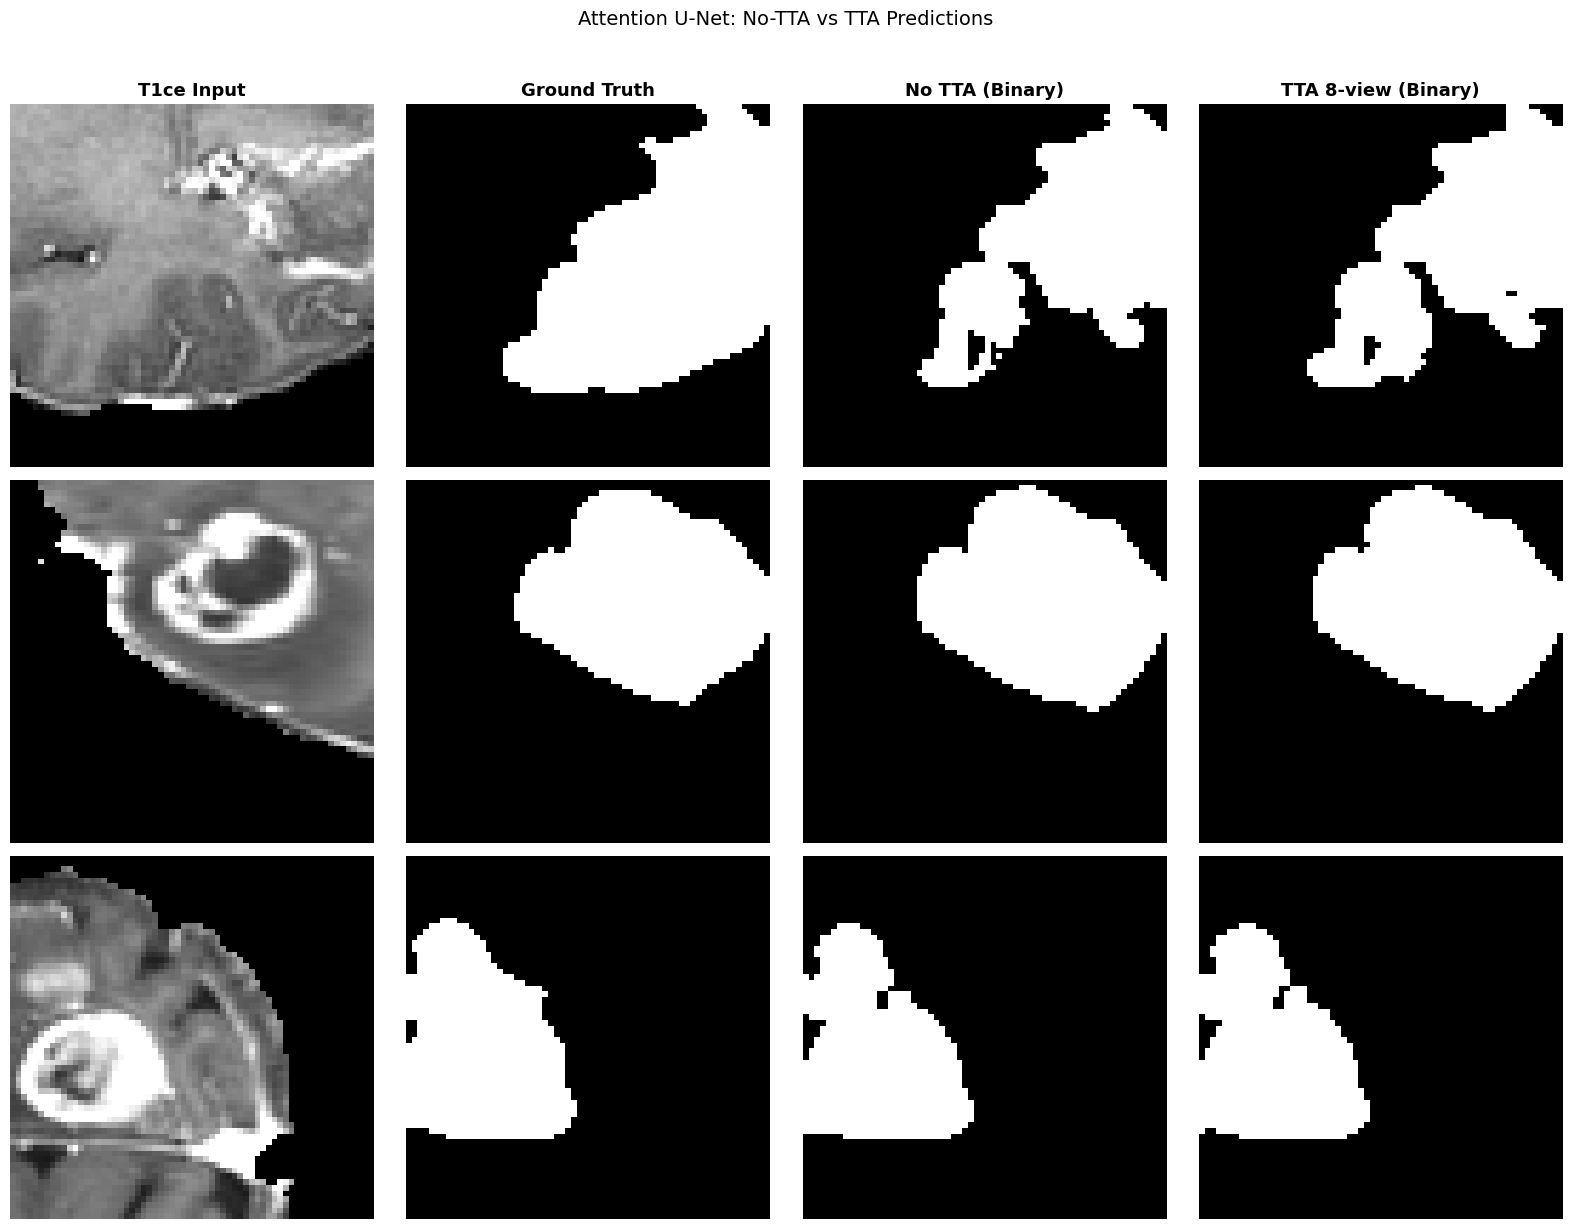

In [19]:
# TTA: 8 views = identity + 7 flip combinations over axes (H, W, D)
import itertools

TTA_AXES = [
    (),          # identity
    (2,),        # flip H
    (3,),        # flip W
    (4,),        # flip D
    (2, 3),      # flip H+W
    (2, 4),      # flip H+D
    (3, 4),      # flip W+D
    (2, 3, 4),   # flip H+W+D
]

@torch.no_grad()
def tta_predict(model, x):
    acc = torch.zeros_like(x[:, :1])   # accumulator: (1,1,H,W,D)
    for axes in TTA_AXES:
        x_aug = x.clone()
        for ax in axes:
            x_aug = x_aug.flip(ax)
        with torch.amp.autocast('cuda'):
            p = torch.sigmoid(model(x_aug).float())
        for ax in reversed(axes):      # un-flip prediction
            p = p.flip(ax)
        acc = acc + p
    return acc / len(TTA_AXES)


@torch.no_grad()
def full_evaluation_tta(model, loader, device, model_name):
    core = model.module if isinstance(model, nn.DataParallel) else model
    core.eval().to(device)

    results = {'dice': [], 'iou': [], 'precision': [], 'recall': [], 'hd95': []}

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        probs_batch = []
        for b in range(x.shape[0]):
            p = tta_predict(core, x[b:b+1])
            probs_batch.append(p)
        probs = torch.cat(probs_batch, dim=0)

        m = compute_metrics(probs, y)
        for k in ['dice', 'iou', 'precision', 'recall']:
            results[k].append(m[k])

        for b in range(x.shape[0]):
            hd = hausdorff_distance_95(probs[b:b+1], y[b:b+1])
            if not np.isnan(hd):
                results['hd95'].append(hd)

    out = {}
    for metric, vals in results.items():
        if vals:
            out[metric] = np.mean(vals)
        else:
            out[metric] = float('nan')
    return out

print('Evaluating Attention U-Net with TTA (8 views × val set)...')
improved_tta_scores = full_evaluation_tta(improved_model, val_loader, device, 'Attention U-Net')

# TTA gain table for Attention U-Net
print('\n TTA GAIN SUMMARY')
print(f' {"Metric":<12} {"No TTA":>12} {"With TTA":>12} {"Gain":>12}')
print('-'*60)
for m in ['dice', 'iou', 'precision', 'recall', 'hd95']:
    i_raw = improved_scores.get(m, float('nan'))
    i_tta = improved_tta_scores.get(m, float('nan'))

    if np.isnan(i_raw) or np.isnan(i_tta):
        print(f' {m.upper():<12} {"N/A":>12} {"N/A":>12} {"N/A":>12}')
        continue

    i_gain = i_tta - i_raw
    i_sign = '+' if i_gain >= 0 else ''

    # For HD95 lower is better
    if m == 'hd95':
        i_note = ' lesser -> better' if i_gain < 0 else ' greater -> worse'
    else:
        i_note = ''

    print(f' {m.upper():<12} {i_raw:>12.4f} {i_tta:>12.4f} {i_sign}{i_gain:>7.4f}{i_note}')
print('============================================================\n')


# Visual comparison: no-TTA vs TTA on the Attention U-Net (Binary Masks)
@torch.no_grad()
def visualize_tta_comparison(model, loader, device, n_samples=3):
    """Side-by-side: Input | GT | no-TTA prediction (Binary) | TTA prediction (Binary)."""
    core = model.module if isinstance(model, nn.DataParallel) else model
    core.eval()

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]
    for col, title in enumerate(['T1ce Input', 'Ground Truth', 'No TTA (Binary)', 'TTA 8-view (Binary)']):
        axes[0, col].set_title(title, fontsize=13, fontweight='bold')

    it = iter(loader)
    for row in range(n_samples):
        try:
            x, y = next(it)
        except StopIteration:
            break
        x1, y1 = x[0:1].to(device), y[0:1]

        with torch.amp.autocast('cuda'):
            p_raw = torch.sigmoid(core(x1).float()).cpu()
        p_tta = tta_predict(core, x1).cpu()

        sums   = y1[0, 0].sum(dim=(0, 1))
        best_d = int(sums.argmax()) if sums.max() > 0 else x1.shape[-1]//2

        inp_sl = np.clip(x[0, 0, :, :, best_d].cpu().numpy(), -3, 3)

        # Convert continuous probabilities to strictly binary masks (0 or 1)
        p_raw_bin = (p_raw[0, 0, :, :, best_d].numpy() > 0.5).astype(np.float32)
        p_tta_bin = (p_tta[0, 0, :, :, best_d].numpy() > 0.5).astype(np.float32)

        slices = [
            (inp_sl,                            'gray', None, None),
            (y1[0, 0,  :, :, best_d].numpy(),   'gray', 0,    1),
            (p_raw_bin,                         'gray', 0,    1),
            (p_tta_bin,                         'gray', 0,    1),
        ]

        for col, (img, cmap, vmin, vmax) in enumerate(slices):
            axes[row, col].imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
            axes[row, col].axis('off')

        d_raw = compute_metrics(p_raw, y1)['dice']
        d_tta = compute_metrics(p_tta, y1)['dice']
        axes[row, 0].set_ylabel(f'Raw Dice: {d_raw:.3f}\nTTA Dice: {d_tta:.3f}', fontsize=12)

    plt.suptitle('Attention U-Net: No-TTA vs TTA Predictions', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

visualize_tta_comparison(improved_model, val_loader, device, n_samples=3)

## 20. Modality Importance — Which MRI Scan Matters Most?

BraTS provides four MRI modalities; this project uses **T1ce** and **FLAIR**.  
We use **gradient-based input attribution**: backpropagate the predicted tumour
probability to the input tensor and take the mean absolute gradient per channel.
A higher value means that modality's voxels had more influence on the prediction.

Evaluating Modality Importance for Attention U-Net...

Modality Importance (gradient attribution):
  FLAIR : 53.2%
  T1CE  : 45.8%

  Most informative modality for tumour segmentation is: FLAIR


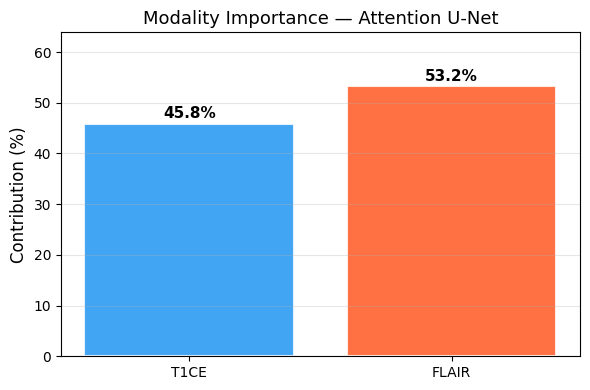

In [20]:
def modality_importance(model, loader, device, modality_names, n_batches=5):
    model.eval()

    channel_grads = [[] for _ in modality_names]

    for batch_idx, (x, y) in enumerate(loader):
        if batch_idx >= n_batches:
            break

        x = x.to(device).requires_grad_(True)
        y = y.to(device)

        logits = model(x)
        probs  = torch.sigmoid(logits)

        tumour_mask = (probs > 0.5).float()
        if tumour_mask.sum() == 0:
            continue

        score = (probs * tumour_mask).sum() / (tumour_mask.sum() + 1e-8)
        score.backward()

        with torch.no_grad():
            grads = x.grad.abs()           # (B, C, H, W, D)
            # Mean absolute gradient per sample per channel
            per_channel = grads.mean(dim=(0, 2, 3, 4))   # (C,)
            for c, val in enumerate(per_channel):
                channel_grads[c].append(val.item())

        x.grad = None

    mean_grads = np.array([np.mean(g) if g else 0.0 for g in channel_grads])
    pct        = 100 * mean_grads / (mean_grads.sum() + 1e-8)

    print("\nModality Importance (gradient attribution):")
    ranked = sorted(zip(modality_names, pct), key=lambda t: -t[1])

    for name, val in ranked:
        print(f"  {name.upper():<6}: {val:.1f}%")

    most_important = ranked[0][0].upper()
    print(f"\n  Most informative modality for tumour segmentation is: {most_important}")

    return dict(zip(modality_names, pct))


def plot_modality_importance(scores_dict, model_name):
    names  = list(scores_dict.keys())
    values = list(scores_dict.values())
    colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0'][:len(names)]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar([n.upper() for n in names], values, color=colors, alpha=0.85,
                  edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Contribution (%)', fontsize=12)
    ax.set_title(f'Modality Importance — {model_name}', fontsize=13)
    ax.set_ylim(0, max(values) * 1.2)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


print('Evaluating Modality Importance for Attention U-Net...')
improved_importance = modality_importance(improved_model, val_loader, device, MODALITIES)
plot_modality_importance(improved_importance, 'Attention U-Net')

## 21. Critical Analysis — Where the Model Succeeds and Fails

/tmp/ipykernel_2596/1112689224.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=10)


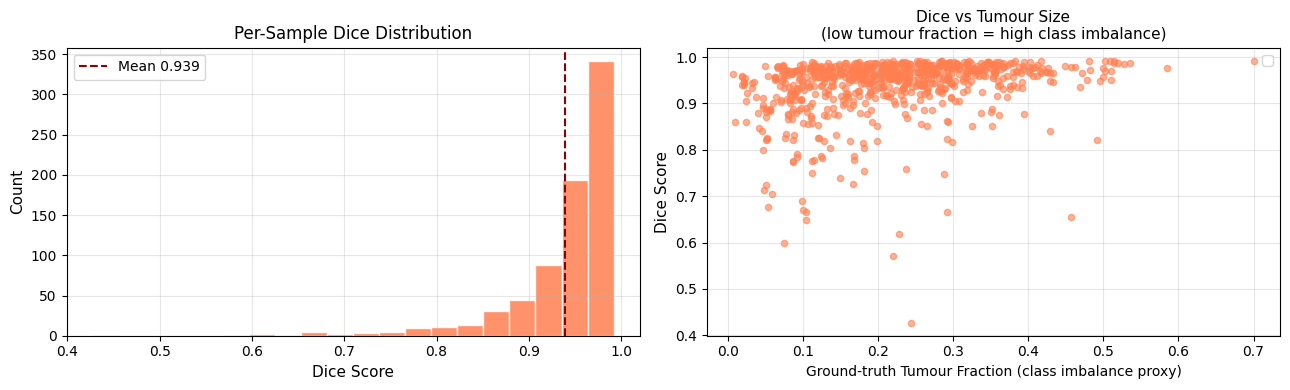


Visualising worst predictions...


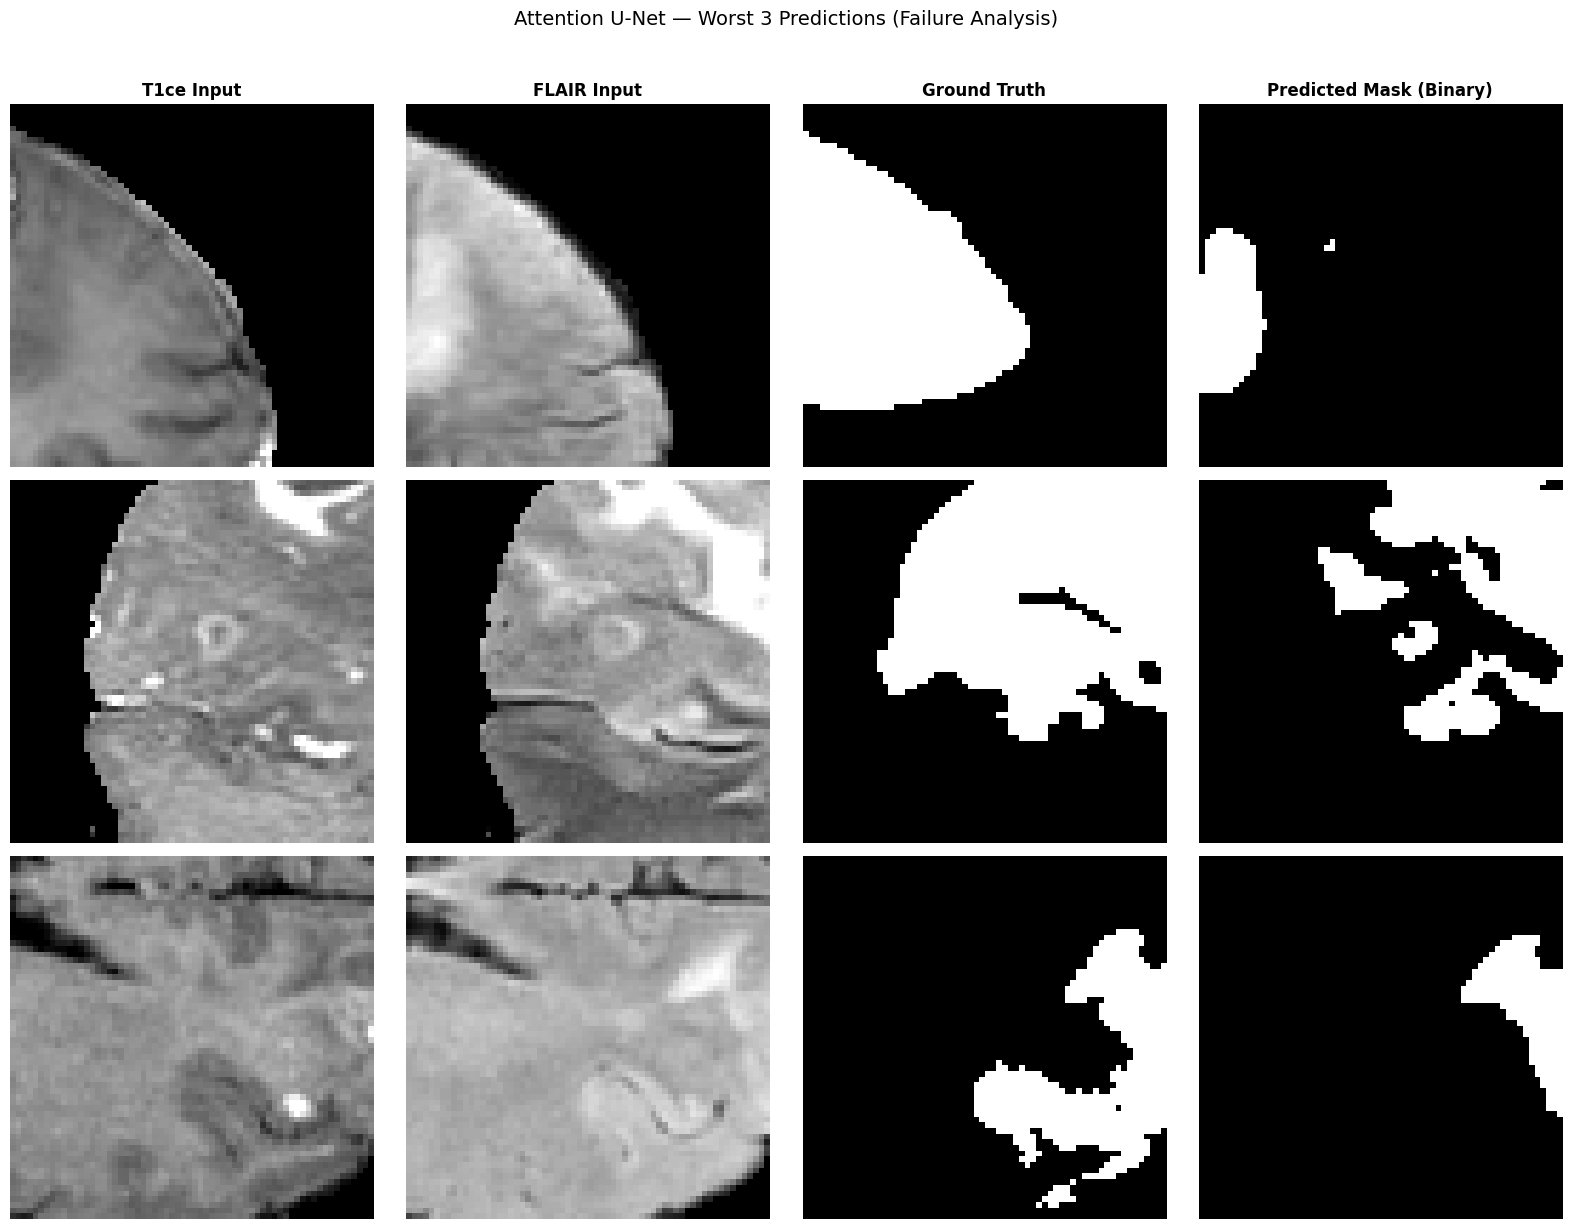


Running noise robustness analysis...


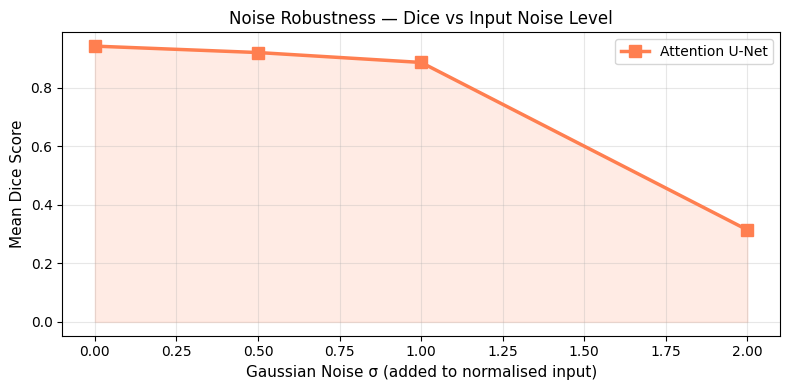


CRITICAL ANALYSIS REPORT
Mean Dice Score:         0.9392
High Performance (>0.8): 95.9% of samples
Severe Failures (<0.3):  0.0% of samples
Tumour Size Correlation: 0.270 (positive = large tumours segment better)
Noise Degradation:       Drop of 0.6274 Dice at max noise (σ=2.0)


In [29]:
## 21a. Per-sample metric distribution
@torch.no_grad()
def collect_per_sample_metrics(model, loader, device):
    # Returns list of dicts with per-sample Dice, IoU, HD95 and tumour fraction.
    model.eval()
    records = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.amp.autocast('cuda'):
            probs = torch.sigmoid(model(x).float())
        for b in range(x.shape[0]):
            m  = compute_metrics(probs[b:b+1], y[b:b+1])
            hd = hausdorff_distance_95(probs[b:b+1], y[b:b+1])
            tf = y[b].mean().item()          # ground-truth tumour fraction
            records.append({**m, 'hd95': hd, 'tumour_frac': tf})
    return records

print('Collecting per-sample metrics...')
improved_records = collect_per_sample_metrics(improved_model, val_loader, device)

dice_impr = [r['dice'] for r in improved_records]
tf_vals   = [r['tumour_frac'] for r in improved_records]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(dice_impr, bins=20, color='coral', alpha=0.85, edgecolor='white')
axes[0].axvline(np.mean(dice_impr), color='darkred', linestyle='--', linewidth=1.5, label=f'Mean {np.mean(dice_impr):.3f}')
axes[0].set_xlabel('Dice Score', fontsize=11)
axes[0].set_ylabel('Count',      fontsize=11)
axes[0].set_title('Per-Sample Dice Distribution', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Dice vs tumour fraction scatter — exposes class-imbalance failure mode
axes[1].scatter(tf_vals, dice_impr, alpha=0.6, s=20, color='coral')
axes[1].set_xlabel('Ground-truth Tumour Fraction (class imbalance proxy)', fontsize=10)
axes[1].set_ylabel('Dice Score', fontsize=11)
axes[1].set_title('Dice vs Tumour Size\n(low tumour fraction = high class imbalance)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

@torch.no_grad()
def visualize_failure_cases(model, loader, device, n_worst=3):
    """Show the n samples with lowest Dice — reveals systematic failure modes."""
    model.eval()
    cases = []
    for x, y in loader:
        x_d, y_d = x.to(device), y.to(device)
        with torch.amp.autocast('cuda'):
            probs = torch.sigmoid(model(x_d).float()).cpu()
        for b in range(x.shape[0]):
            m = compute_metrics(probs[b:b+1], y[b:b+1])
            cases.append((m['dice'], x[b], y[b], probs[b]))

    cases.sort(key=lambda t: t[0])   # ascending Dice -> worst first

    fig, axes = plt.subplots(n_worst, 4, figsize=(16, 4*n_worst))
    if n_worst == 1:
        axes = axes[np.newaxis, :]
    axes[0, 0].set_title('T1ce Input',               fontsize=12, fontweight='bold')
    axes[0, 1].set_title('FLAIR Input',              fontsize=12, fontweight='bold')
    axes[0, 2].set_title('Ground Truth',             fontsize=12, fontweight='bold')
    axes[0, 3].set_title('Predicted Mask (Binary)',  fontsize=12, fontweight='bold')

    for row, (dice, x_s, y_s, p_s) in enumerate(cases[:n_worst]):
        sums   = y_s[0].sum(dim=(0,1))
        best_d = int(sums.argmax()) if sums.max() > 0 else x_s.shape[-1]//2

        t1ce_sl  = np.clip(x_s[0, :, :, best_d].numpy(), -3, 3)
        flair_sl = np.clip(x_s[1, :, :, best_d].numpy(), -3, 3) if x_s.shape[0] > 1 else t1ce_sl
        gt_sl    = y_s[0, :, :, best_d].numpy()

        # Convert to strict binary mask for visualization
        pr_sl_bin = (p_s[0, :, :, best_d].numpy() > 0.5).astype(np.float32)

        axes[row, 0].imshow(t1ce_sl,  cmap='gray');  axes[row, 0].axis('off')
        axes[row, 1].imshow(flair_sl, cmap='gray');  axes[row, 1].axis('off')
        axes[row, 2].imshow(gt_sl,    cmap='gray', vmin=0, vmax=1); axes[row, 2].axis('off')
        axes[row, 3].imshow(pr_sl_bin, cmap='gray', vmin=0, vmax=1); axes[row, 3].axis('off')
        axes[row, 0].set_ylabel(f'Dice={dice:.3f}', fontsize=12)

    plt.suptitle(f'Attention U-Net — Worst {n_worst} Predictions (Failure Analysis)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

print('\nVisualising worst predictions...')
visualize_failure_cases(improved_model, val_loader, device, n_worst=3)

## Noise robustness study
@torch.no_grad()
def noise_robustness(model, loader, device, noise_stds=(0.0, 0.5, 1.0, 2.0), n_batches=10):
    """Measure Dice degradation as Gaussian noise σ increases."""
    model.eval()
    results = {s: [] for s in noise_stds}

    for batch_idx, (x, y) in enumerate(loader):
        if batch_idx >= n_batches:
            break
        y = y.to(device)
        for sigma in noise_stds:
            x_noisy = (x + sigma * torch.randn_like(x)).to(device)
            with torch.amp.autocast('cuda'):
                probs = torch.sigmoid(model(x_noisy).float())
            m = compute_metrics(probs, y)
            results[sigma].append(m['dice'])

    return {s: np.mean(v) for s, v in results.items()}

print('\nRunning noise robustness analysis...')
impr_noise = noise_robustness(improved_model, val_loader, device)

sigmas    = sorted(impr_noise.keys())
impr_vals = [impr_noise[s] for s in sigmas]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sigmas, impr_vals, 's-', color='coral', linewidth=2.5, label='Attention U-Net', markersize=8)
ax.fill_between(sigmas, impr_vals, alpha=0.15, color='coral')
ax.set_xlabel('Gaussian Noise σ (added to normalised input)', fontsize=11)
ax.set_ylabel('Mean Dice Score', fontsize=11)
ax.set_title('Noise Robustness — Dice vs Input Noise Level', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

mean_dice_impr = np.mean(dice_impr)
high_dice_impr = np.mean([d > 0.8 for d in dice_impr]) * 100
low_dice_impr  = np.mean([d < 0.3 for d in dice_impr]) * 100

# Correlation: tumour fraction vs Dice
tf_arr   = np.array(tf_vals)
di_arr   = np.array(dice_impr)
valid_idx = tf_arr > 0
corr = np.corrcoef(tf_arr[valid_idx], di_arr[valid_idx])[0, 1] if valid_idx.any() else 0.0

noise_drop_impr = impr_vals[0] - impr_vals[-1]

print('\nCRITICAL ANALYSIS REPORT')
print(f'Mean Dice Score:         {mean_dice_impr:.4f}')
print(f'High Performance (>0.8): {high_dice_impr:.1f}% of samples')
print(f'Severe Failures (<0.3):  {low_dice_impr:.1f}% of samples')
print(f'Tumour Size Correlation: {corr:.3f} (positive = large tumours segment better)')
print(f'Noise Degradation:       Drop of {noise_drop_impr:.4f} Dice at max noise (σ=2.0)')
print('====================================================')



## 16. Training Curves

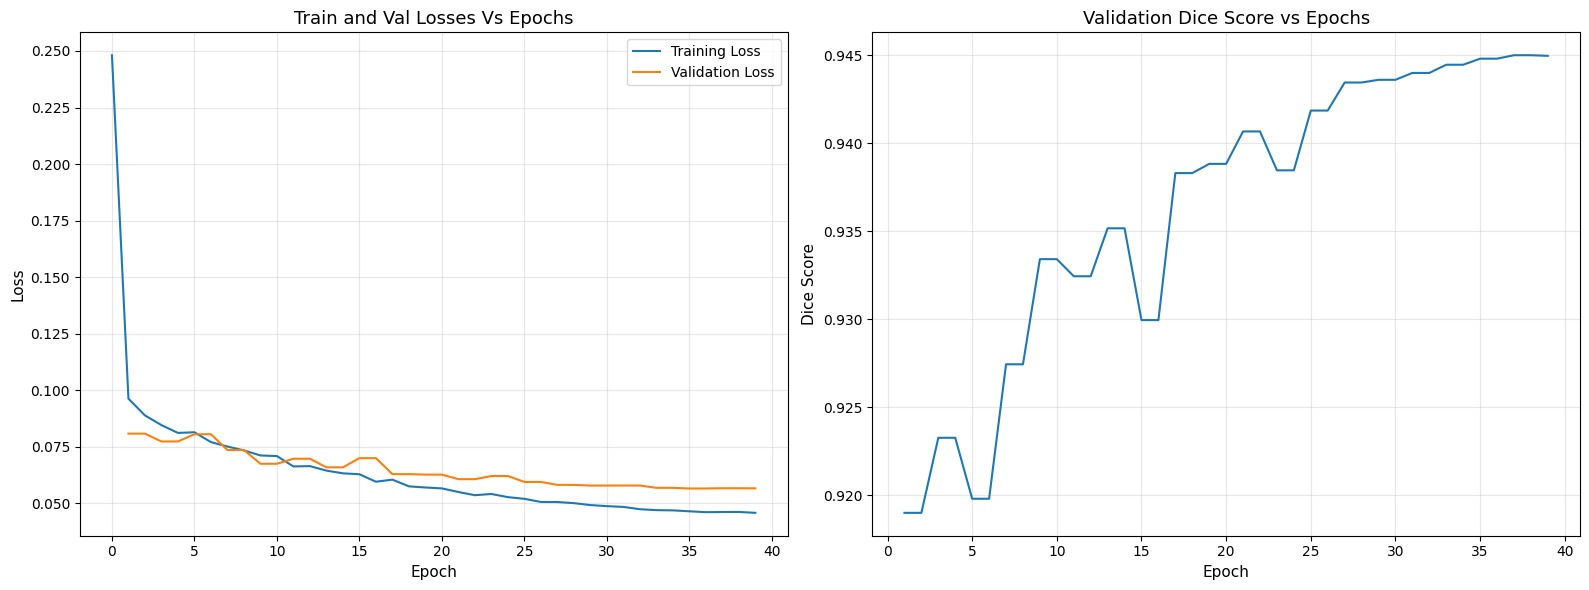

In [31]:
## 22. Training Progress Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_cfg  = [
    ('train_loss', 'Training Loss',   'Loss'),
    ('val_loss',   'Validation Loss', 'Loss'),
    ('val_dice',   'Validation Dice', 'Dice Score'),
]

axes[0].plot(improved_history['train_loss'], label='Training Loss')
axes[0].plot(improved_history['val_loss'], label='Validation Loss')
axes[0].set_title("Train and Val Losses Vs Epochs", fontsize=13)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(improved_history['val_dice'])
axes[1].set_title("Validation Dice Score vs Epochs", fontsize=13)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Dice Score', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
